# Module 4 - Deutsch algorithm
---

In [15]:
import os
import math
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.visualization import array_to_latex, plot_histogram
from IPython.display import display


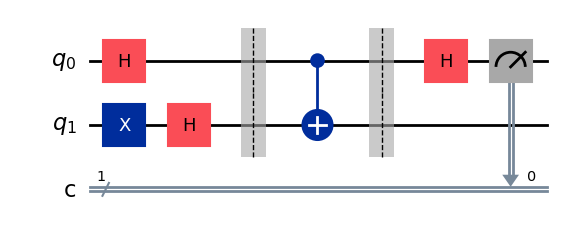

In [12]:
circuit = QuantumCircuit(2, 1)

circuit.h(0)
circuit.x(1)
circuit.h(1)
circuit.barrier()

circuit.cx(0, 1)
circuit.barrier()

circuit.h(0)
circuit.measure(0, 0)
circuit.draw('mpl')

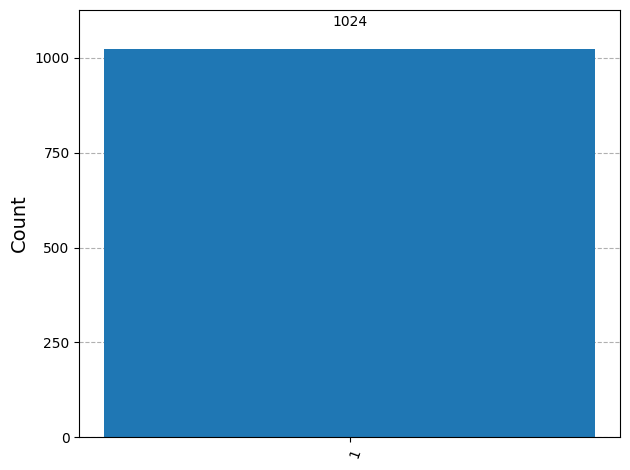

In [13]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit)
result = job.result()
counts = result.get_counts(compiled_circuit)

display(qiskit.visualization.plot_histogram(counts))

### Run this on a real computer

In [18]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print (f'Least busy backend: {backend.name}')
print (f'  Pending jobs: {backend.status().pending_jobs}')
print (f'  Number of qubits: {len(backend.properties().qubits)}')

Least busy backend: ibm_brisbane
  Pending jobs: 68
  Number of qubits: 127


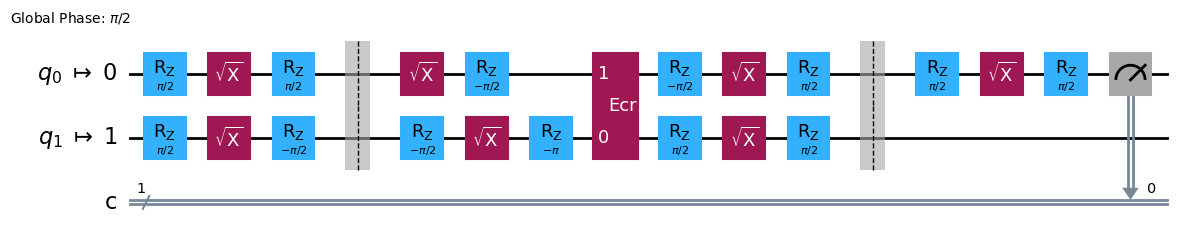

In [19]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa = pm.run(circuit)
 
isa.draw("mpl", idle_wires=False)

In [20]:
sampler = Sampler(backend)
job = sampler.run([isa], shots=1000) 

In [28]:
print (f'Job status: {job.status()}')

if job.status() == 'DONE':
    result = job.result()
    print(f">>> Result: {result}")
    counts = result[0].data.meas.get_counts()
    print(f"Counts: {counts}")     
    plot_histogram(counts, title="Counts from Qiskit Runtime Sampler")

Job status: QUEUED
